In [9]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

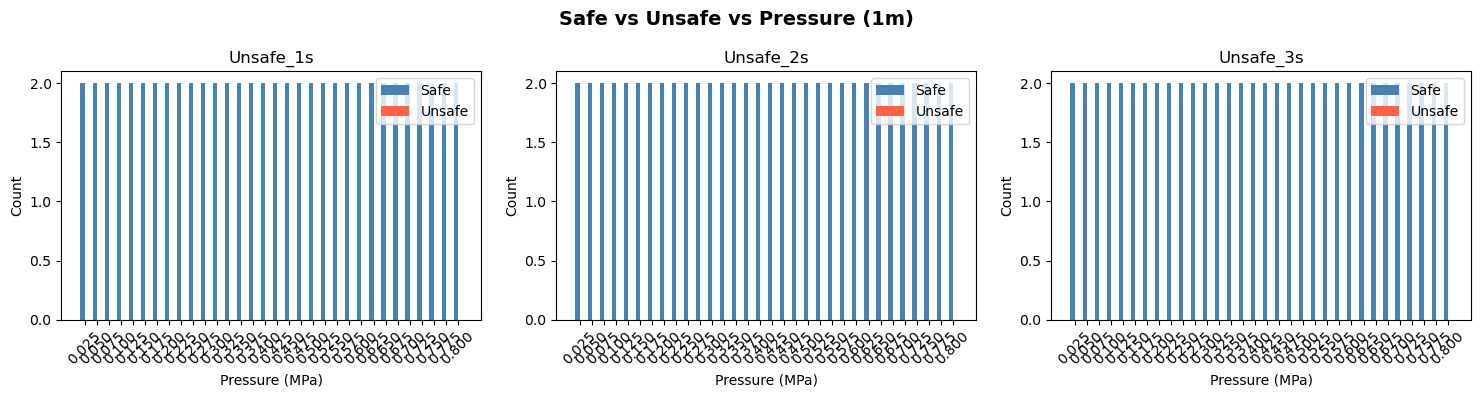

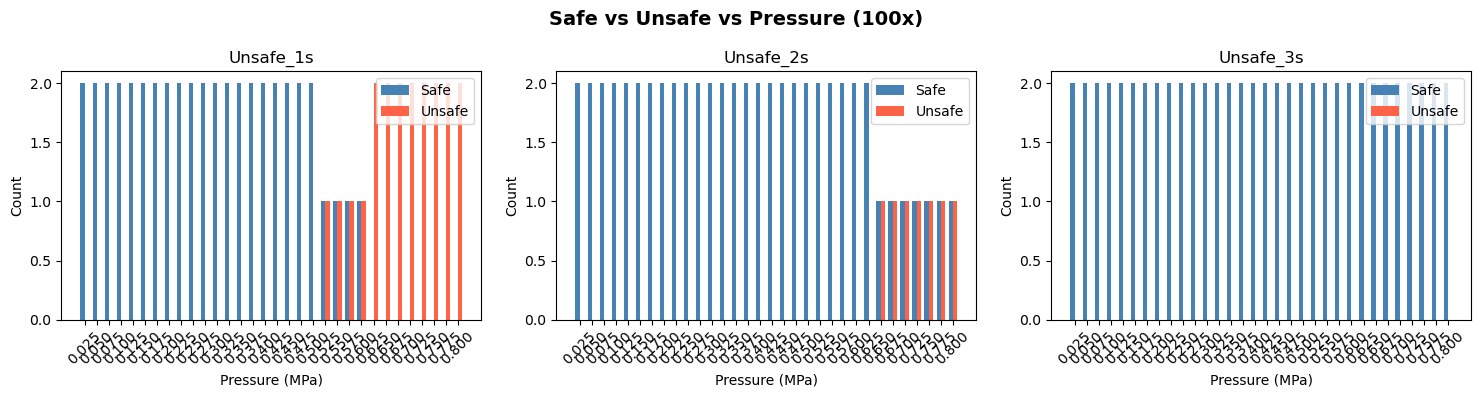

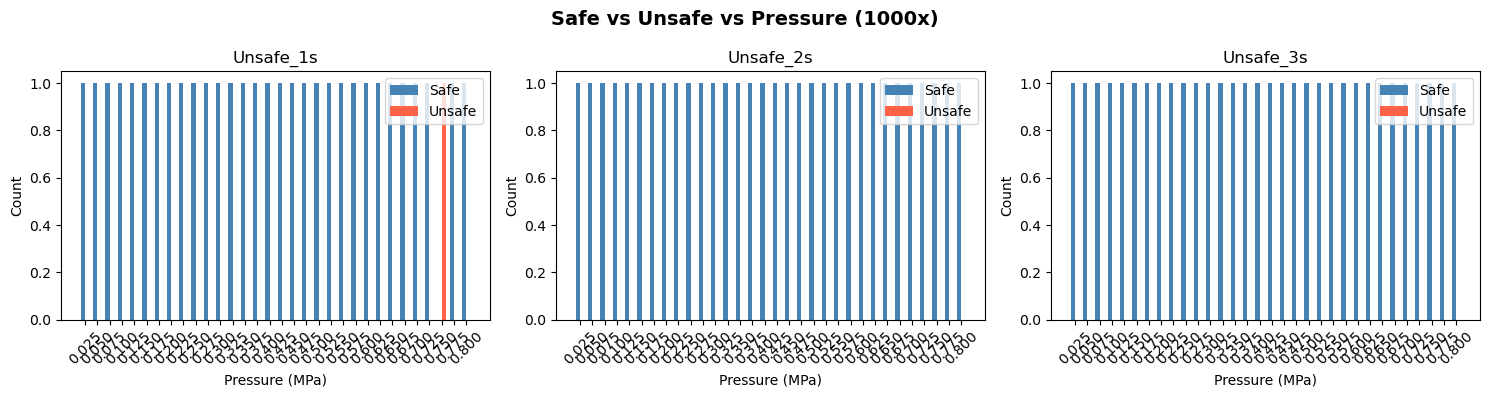

In [14]:
df = pd.read_csv("PCD_Harmonic_Features.csv")

# Create pressure column
pressures = np.arange(0.025, 0.825, 0.025)
df["Pressure (MPa)"] = np.tile(pressures, len(df) // len(pressures))
df["Pressure (MPa)"] = df["Pressure (MPa)"].round(3)

# Define your dilutions (adjust names if needed)
dilutions = ["1m", "100x", "1000x"]  # add others if you have 5 total

for dilution in dilutions:
    df_dil = df[df["File"].str.contains(dilution, na=False)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    for ax, col in zip(axes, ["Unsafe_1s", "Unsafe_2s", "Unsafe_3s"]):
        
        grouped = df_dil.groupby(["Pressure (MPa)", col]).size().unstack(fill_value=0)

        # Ensure both Safe (0) and Unsafe (1) exist
        for val in [0, 1]:
            if val not in grouped.columns:
                grouped[val] = 0

        grouped = grouped.sort_index()

        x = np.arange(len(grouped.index))
        width = 0.35

        # Bars
        ax.bar(x - width/2, grouped[0], width, label="Safe", color="steelblue")
        ax.bar(x + width/2, grouped[1], width, label="Unsafe", color="tomato")

        # Labels
        ax.set_xticks(x)
        ax.set_xticklabels([f"{p:.3f}" for p in grouped.index], rotation=45)
        ax.set_title(col)
        ax.set_xlabel("Pressure (MPa)")
        ax.set_ylabel("Count")
        ax.legend()

    plt.suptitle(f"Safe vs Unsafe vs Pressure ({dilution})", fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()


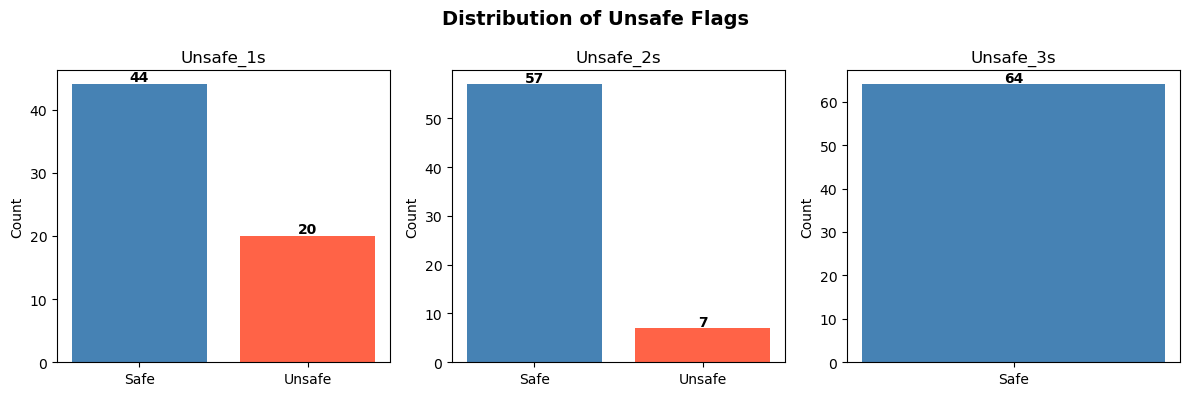

In [11]:
# check for both experiments (1 and 2) with 100x dilution both 
df_100 = df[df["File"].str.contains("100x", na=False)]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for ax, col in zip(axes, ["Unsafe_1s", "Unsafe_2s", "Unsafe_3s"]):
    counts = df_100[col].value_counts().sort_index()
    labels = counts.index.map({0: "Safe", 1: "Unsafe"}) if set(counts.index) <= {0, 1} else counts.index.astype(str)
    ax.bar(labels, counts.values, color=["steelblue", "tomato"][:len(counts)])
    ax.set_title(col)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.suptitle("Distribution of Unsafe Flags", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

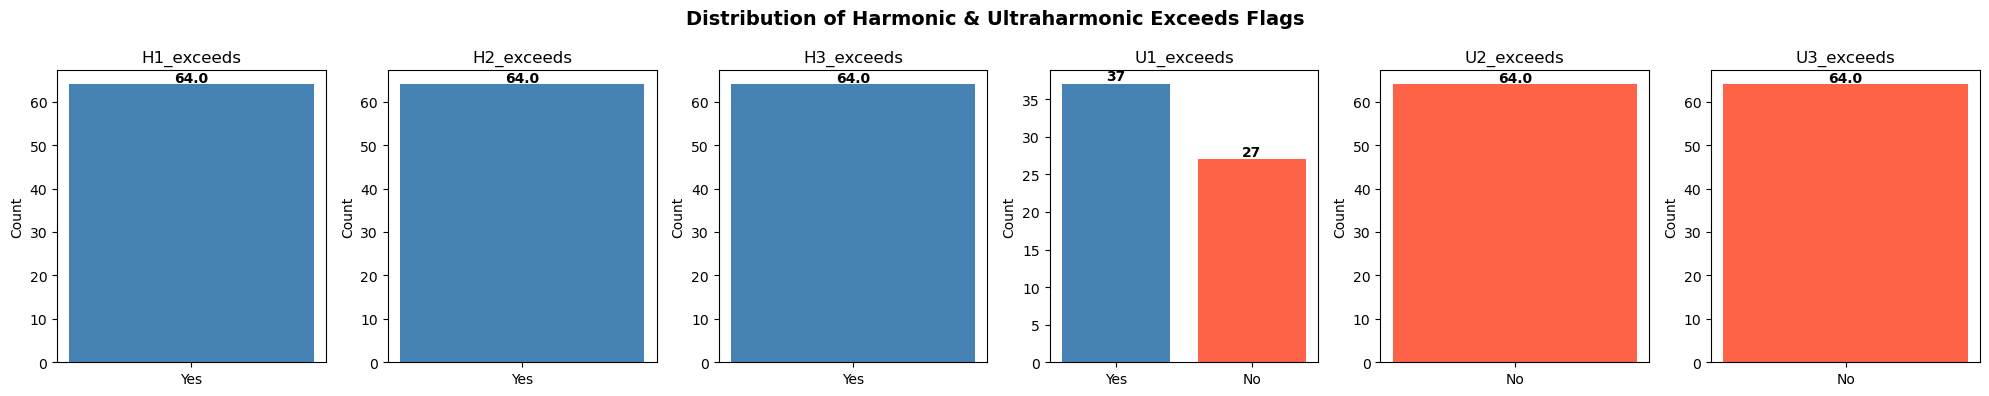

In [12]:
fig, axes = plt.subplots(1, 6, figsize=(20, 4))

for ax, col in zip(axes, ["H1_exceeds", "H2_exceeds", "H3_exceeds", "U1_exceeds", "U2_exceeds", "U3_exceeds"]):
    counts = df_100[col].value_counts().reindex([1, 0])
    labels = counts.index.map({0: "No", 1: "Yes"}) if set(counts.index) <= {0, 1} else counts.index.astype(str)
    color_map = {0: "tomato", 1: "steelblue"}
    colors = [color_map.get(i, "gray") for i in counts.index]
    ax.bar(labels, counts.values, color=colors)
    ax.set_title(col)
    ax.set_ylabel("Count")
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.5, str(v), ha="center", fontweight="bold")

plt.suptitle("Distribution of Harmonic & Ultraharmonic Exceeds Flags", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()